In [35]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [49]:
api = wandb.Api()

In [37]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s14/distill-layerwise/run3/distill-varying-student"

In [50]:
def read_data(
    teacher,
    arr_students,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    contamination_level,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": {"$in": arr_students}},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics" in run.summary:
            count += 1
            print("> ", run.config["dataset"])
            continue
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        compression_rate = int(run.config["student"].split("compr")[1])
        
        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                student=run.config["student"],
                compression_rate=compression_rate,
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    if count > 0:
        print(f"We have {count} failed runs!")
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["compression_rate"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    arr_students=[
        "resnet18cifarcompr2",
        "resnet18cifarcompr4",
        "resnet18cifarcompr8",
        "resnet18cifarcompr16",
        "resnet18cifarcompr32",
    ],
    policy="basis-identity:random--uncentered",
    training_size=1.0,
    contamination_level=0.0,
    lambda_task=0.0,
    lambda_kd=1.0,
    verbose=True,
)

summary

we have 100 runs
df.shape: (5, 11)


compression_rate val_acc                 val_agreement                  \
                      mean       std count          mean       std count   
0                2  0.8269  0.085642    20        0.8301  0.080544    20   
1                4  0.8232  0.086590    20        0.8243  0.080452    20   
2                8  0.8236  0.082856    20        0.8287  0.074924    20   
3               16  0.8169  0.086413    20        0.8218  0.084198    20   
4               32  0.7844  0.097423    20        0.7891  0.095680    20   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                           0.7761  0.108571    20      0.8677  
1                           0.7717  0.108020    20      0.8677  
2                           0.7734  0.104140    20      0.8677  
3                           0.7666  0.109974    20      0.8677  
4                           0.7372  0.118418    20      0.8677

In [20]:
read_data(
    teacher="cifar100-resnet18-v1",
    arr_students=[
        "resnet18cifarcompr2",
        "resnet18cifarcompr4",
        "resnet18cifarcompr8",
        "resnet18cifarcompr16",
        "resnet18cifarcompr32",
    ],
    policy="basis-identity:prca-sortabs--uncentered",
    training_size=1.0,
    contamination_level=0.5,
    lambda_task=0.0,
    lambda_kd=1.0,
    verbose=True,
)

we have 100 runs
df.shape: (5, 11)


compression_rate val_acc                 val_agreement                  \
                      mean       std count          mean       std count   
0                2  0.7918  0.097706    20        0.8100  0.082531    20   
1                4  0.7724  0.099772    20        0.7853  0.089450    20   
2                8  0.7516  0.101284    20        0.7649  0.092662    20   
3               16  0.7317  0.108982    20        0.7425  0.100941    20   
4               32  0.7206  0.107541    20        0.7318  0.100130    20   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                           0.7476  0.112926    20      0.8556  
1                           0.7266  0.116547    20      0.8556  
2                           0.7065  0.117591    20      0.8556  
3                           0.6866  0.123674    20      0.8556  
4                           0.6757  0.122643    20      0.8556

In [21]:
# def read_data_baseline(
#     teacher,
#     student,
#     lambda_task,
#     lambda_kd,
#     training_size,
#     arr_contamination_levels,
#     verbose=False,
    
# ):
#     raise NotImplementedError("to be run")
#     runs = api.runs(
#         f'p16i/xaikd-distillation-layerwise-ep2',
#         {
#         "$and": [
#             {"group": EXPERIMENT_GROUP + "-baselinerun"},
#             {"config.teacher": teacher},
#             {"config.student": student},
#             {"config.lambda_task": lambda_task},
#             {"config.lambda_kd": lambda_kd},
#             {"config.policy": "basis-identity:random--uncentered"},
#             {"config.training_size": training_size},
#             {"config.contamination_level": {"$in": arr_contamination_levels}},
#         ]}
#     )
    
#     if verbose:
#         print(f"we have {len(runs)} runs")
    
#     rows = []
    
#     for run in runs:
#         seed = run.config["seed"]
         
#         k = np.argmax(run.summary["arr_metrics"]["val_acc"])
#         best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
#         best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
#         best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]

#         assert run.config["lambda_layer"] is not None

#         rows.append(
#             dict(
#                 best_epoch=k,
#                 seed=seed, 
#                 lambda_task=run.config["lambda_task"],
#                 lambda_kd=run.config["lambda_kd"],
#                 lambda_layer=run.config["policy_lambda_layer"],
#                 training_size=run.config["training_size"],
#                 contamination_level=run.config["contamination_level"],

#                 val_acc=best_val_acc, 
#                 val_agreement=best_val_agreement,
#                 val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
#                 teacher_acc=run.summary["teacher_acc"],
#             )
#         )

    
    
    
#     df = pd.DataFrame(rows)

      
#     df = df.groupby(by=["training_size", "contamination_level"]).agg(
#         {
#             "val_acc": ["mean", "std", "count"],
#             "val_agreement": ["mean", "std", "count"],
#             "val_agreement_on_teacher_correct": ["mean", "std", "count"],
#             "teacher_acc": ["mean"]
#         }
#     ).reset_index()
    
#     np.testing.assert_allclose(
#         df["val_acc"]["count"].values,
#         20,
#         err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
#     )

#     if verbose:
#         print(f"df.shape: {df.shape}")
#     return df

# read_data_baseline(
#     teacher="cifar100-resnet18-v1",
#     student="resnet18cifarcompr2",
#     training_size=1.0,
#     arr_contamination_levels=[0.0],
#     lambda_task=0.0,
#     lambda_kd=1.0
# )

# Comparison on `training-size` and `contamination-level`

we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)


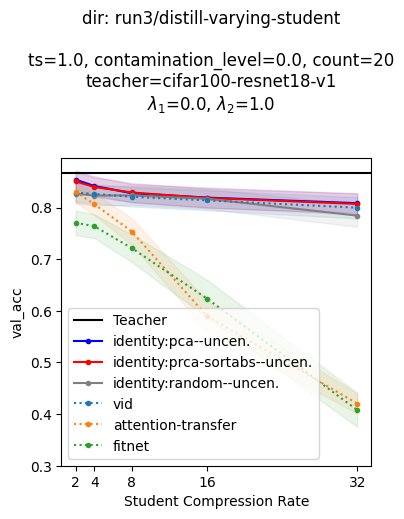

In [56]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "identity") \
        .replace("uncentered", "uncen.")

    
    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher,
    policies, 
    contamination_level,
    show_legend=True,
    include_baseline=True
):
    
    training_size = 1.0
        
    arr_students = [
        "resnet18cifarcompr2",
        "resnet18cifarcompr4",
        "resnet18cifarcompr8",
        "resnet18cifarcompr16",
        "resnet18cifarcompr32",
    ]
        
    lambda_kd = 1.0
    lambda_task = 0.0

    
        

    col = "val_acc"
    
    ncols = 1
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    
    for pix, policy in enumerate(policies):

        
        df = read_data(
            teacher=teacher,
            arr_students=arr_students,
            policy=policy,

            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            contamination_level=contamination_level,
            training_size=training_size,
            verbose=True
        )
        

        ticks = df["compression_rate"]
        

            
        # visualize baseline
        if pix == 0:

            plt.axhline(
                df["teacher_acc"].values[-1],
                ls="-",
                color="k",
                label="Teacher"
            )

        # here, we take the first value.
        # the query function already checks that the value is expected
        count = df[col]["count"].values[-1]

        mean = df[col]["mean"]
        stderr = df[col]["std"] / (count ** 0.5)

        plt.plot(
            ticks,
            mean,
            marker=".",
            label=alias(policy),
            ls=ls(policy),
            color=color(policy)
        )

        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )

    plt.xlabel("Student Compression Rate")
    plt.xticks(ticks)
    plt.ylabel(col)
    plt.ylim(bottom=0.3)

    plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"ts={training_size}, contamination_level={contamination_level}, count={count}",
            f"teacher={teacher}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    contamination_level=0.0,
    policies = [ 
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
    include_baseline=False
) 

we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)
we have 100 runs
df.shape: (5, 11)


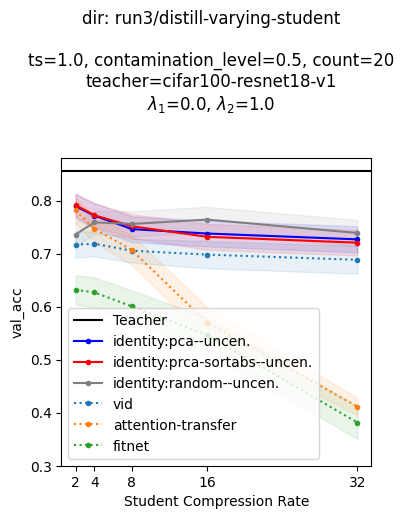

In [57]:
viz_distillation(
    teacher = "cifar100-resnet18-v1",
    contamination_level=0.5,
    policies = [ 
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
    include_baseline=False
) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set according to a hyperparameter optimization. We vary the size of the student model as follows:


|Role| Name | $d_1$ | $d_2$ | $d_3$ | $d_4$  |
|:---:|------:|:-:|:-:|:-:|:-:|
|Teacher| `cifar100-resnet18-v1`  | 64 | 128 |256 | 512 |
|Student| `resnet18cifarcompr2` | 32 | 64 | 128 | 256 |
|Student| `resnet18cifarcompr4` | 32 | 64 | 64 | 128 |
|Student| `resnet18cifarcompr8` | 32 | 64 | 32 | 64 |
|Student| `resnet18cifarcompr16` | 32 | 64 | 16 | 32 |
|Student| `resnet18cifarcompr32` | 32 | 64 | 8 | 16 |
|Student| `resnet18cifarcompr64` | 32 | 64 | 4 | 8 |


*Aims:* 
- Investigate the influence of the policy on the compresssion. A good policy w.r.t. compression should allow the distillation of small models to work well. 


*Conclusion:*
- We see that `pca` and `prca` can maintain their accuracy as the student compression rate increases.
- However, `random` and `vid` seem to also have the properly. 
- `fitnet` and `attention-transfer` seems to be underperform. 
    - This could be due to the value $\lambda_3$.

*Following Questions*
- Why does `random` work well? 
    - Hypothesis: this result could confound with the size of `layer1` and `layer2`. In particular, due to the small size of images, representation at the two layers are good enough to make classification. As a result, keep the  dimensions of the two layers the same preserves the level of accuracy.
    
- why does `vid` work well? 
    - what happen if we add or reduce its adapter's number of layers.?
